# Customer 360 - Exploratory Data Analysis

This notebook focuses on performing Exploratory Data Analysis (EDA) to understand customer behavior and identify meaningful patterns, trends, and relationships within the Customer 360 dataset.

## Import Libararies

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline 
sns.set_theme(style="whitegrid") 
palette = ['lightgreen' , 'indianred']

import warnings 
warnings.filterwarnings('ignore' , category= FutureWarning)

## Load Cleaned-Dataset

In [2]:
df_cleaned = pd.read_csv('../data/processed/customer_360_cleaned.csv')

## Churn distribution


In [3]:
churn_counts = df_cleaned["Churn"].value_counts()
churn_pct = df_cleaned["Churn"].value_counts(normalize=True) * 100

churn_df = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_pct.round(2)
})

churn_df

,Count,Percentage
Churn,,
No,2456,81.87
Yes,544,18.13


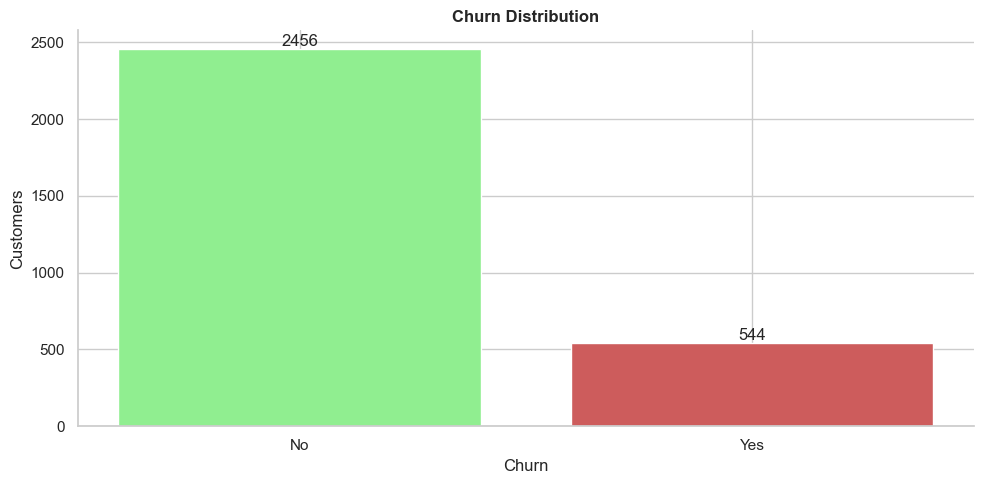

In [4]:
categories = churn_df.index
values = churn_df['Count']

fig , ax = plt.subplots(1,1 , figsize = (10,5))

bars = ax.bar(categories,values,color = palette)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2 ,
            height ,str(height),ha = 'center' ,va='bottom')

ax.spines['top'].set_color('None')
ax.spines['right'].set_color('None')

ax.set_xlabel('Churn')
ax.set_ylabel('Customers')
ax.set_title('Churn Distribution' , fontweight = 'bold')

plt.tight_layout()
plt.savefig('../images/Churn Distribution.png')

plt.show()

#### Insight

The target variable **Churn** is imbalanced:

- **No Churn:** 2,456 customers (**81.87%**)
- **Churn:** 544 customers (**18.13%**)

This means that the majority of customers did not churn, while a smaller proportion of customers churned.

## Churn by Contract Type

In [5]:
churn_by_contract = pd.crosstab(
    df_cleaned["ContractType"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

churn_by_contract

Churn,No,Yes
ContractType,,
Month-to-month,73.392857,26.607143
One year,91.277641,8.722359
Two year,94.861660,5.138340


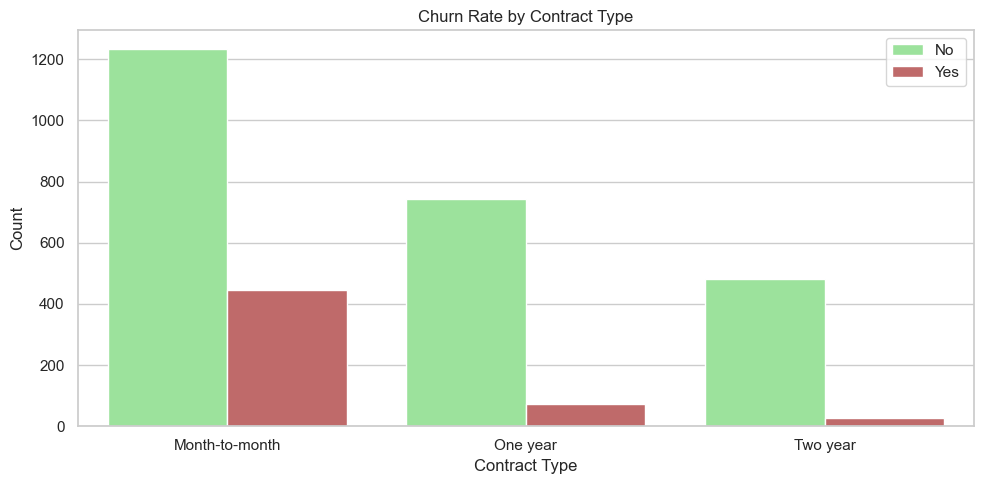

In [6]:
plt.figure(figsize= (10,5))

sns.countplot(data=df_cleaned, x='ContractType' , 
            hue= 'Churn' ,hue_order=['No','Yes'], palette=palette)

plt.ylabel('Count')
plt.xlabel('Contract Type')
plt.title('Churn Rate by Contract Type')

plt.legend()
plt.tight_layout()

plt.savefig('../images/Churn by Contract Type.png')
plt.show()

#### Insight
Month-to-month customers show a higher churn tendency compared with customers on longer-term contracts.

## Churn By Auto Pay

In [7]:
churn_by_autopay = pd.crosstab(
    df_cleaned['AutoPay'],
    df_cleaned['Churn'],
    normalize='index'
    ) * 100

churn_by_autopay.round(2)

Churn,No,Yes
AutoPay,,
No,76.60,23.40
Yes,85.99,14.01


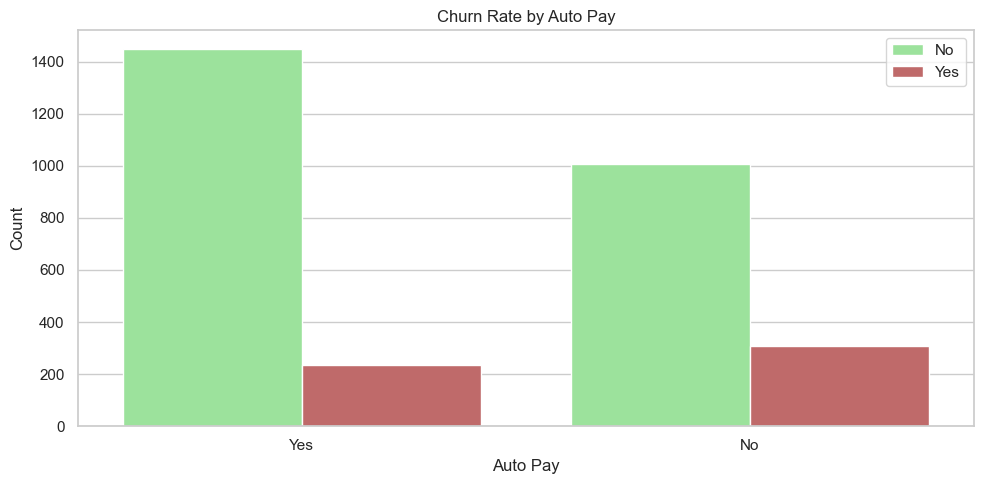

In [8]:
plt.figure(figsize= (10,5))

sns.countplot(data=df_cleaned, x='AutoPay' , 
            hue= 'Churn' ,hue_order=['No','Yes'], palette=palette)

plt.ylabel('Count')
plt.xlabel('Auto Pay')
plt.title('Churn Rate by Auto Pay')

plt.legend()
plt.tight_layout()

plt.savefig('../images/Churn by Auto Pay.png')
plt.show()

#### Insight

The churn rate differs noticeably based on whether customers use **AutoPay**:

- Customers **without AutoPay** have a churn rate of **23.40%**.
- Customers **with AutoPay** have a lower churn rate of **14.01%**.

This shows that customers using AutoPay are less likely to churn in this dataset. The difference suggests that **AutoPay may be associated with better customer retention**.

## Churn By Satisfaction Score    

In [9]:
churn_by_SatisfactionScore = pd.crosstab(
    df_cleaned['SatisfactionScore'],
    df_cleaned['Churn'], 
    normalize='index'
) * 100 

churn_by_SatisfactionScore.round(2)

Churn,No,Yes
SatisfactionScore,,
1.0,55.84,44.16
2.0,71.43,28.57
3.0,81.62,18.38
4.0,84.67,15.33
5.0,88.93,11.07


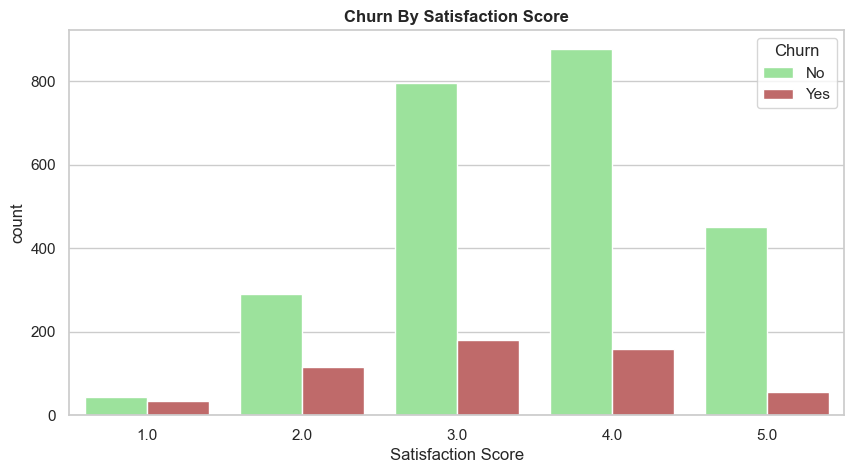

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(data=df_cleaned , x='SatisfactionScore' ,
              hue='Churn' , hue_order=['No','Yes'] , palette= palette)

plt.xlabel('Satisfaction Score')
plt.title('Churn By Satisfaction Score', fontweight = 'bold')

plt.savefig('../images/Churn By Satisfaction Score.png')
plt.show()

#### Insight

**Strong Inverse Relationship**: As customer satisfaction increases, the churn rate significantly decreases.

**Lowest Satisfaction (Score 1.0)**: Has the highest churn rate at 44.16%.

**Highest Satisfaction (Score 5.0)**: Has the lowest churn rate at 11.07%.

**Highest Churn Volume**: Scores 3.0 and 4.0 represent the vast majority of total customers, with Score 3.0 generating the highest absolute count of churned customers (18.38% churn rate).

**Retention Pool**: Customers with scores of 4.0 and 5.0 exhibit strong retention, with non-churn percentages reaching 84.67% and 88.93%, respectively.

## Numerical distributions

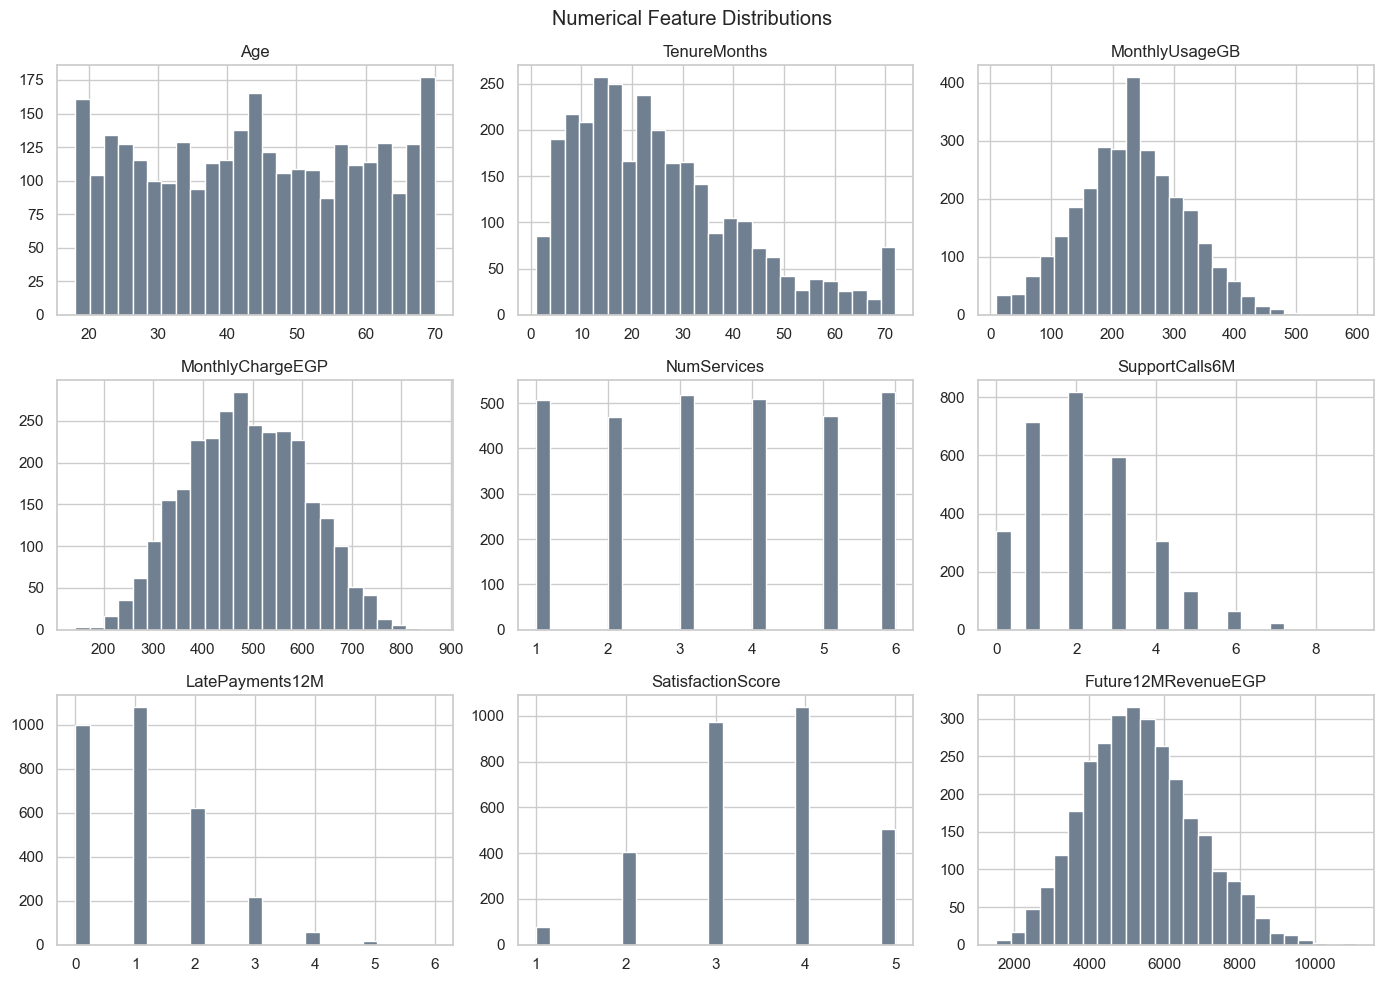

In [11]:
numeric_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()

df_cleaned[numeric_cols].hist(figsize=(14, 10), bins=25,color = 'slategray')

plt.suptitle('Numerical Feature Distributions')

plt.tight_layout()

plt.savefig('../images/Numerical Distribution.png')
plt.show()


#### Insight

**Tenure**: Higher density of customers in early tenure months (0–20 months), where churn vulnerability is typically highest.

**Support Calls & Late Payments**: Most customers have 0–3 late payments and 1–3 support calls in the last 6–12 months.

**Services & Revenue**: Number of services subscribed is evenly distributed (1 to 6 services), with projected 12-month revenue centered around 5,000 EGP.   